Hola **Carlos**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

PASO 1: PREPARACIÓN Y CARGA DE DATOS
¿Qué hacer?

Cargar el dataset de Model Fitness
Explorar la estructura de los datos
Identificar las variables disponibles


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans

# Cargar datos
df = pd.read_csv('/datasets/gym_churn_us.csv')

# Exploración inicial
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())

Forma del dataset: (4000, 14)

Primeras 5 filas:
   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequenc

PASO 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
¿Qué analizar?

Distribución de la variable objetivo (churn)
Estadísticas descriptivas
Valores faltantes
Correlaciones entre variables
Preguntas clave:

¿Qué porcentaje de clientes abandona?
¿Cuáles son las características más comunes?
¿Hay patrones evidentes?

In [2]:
# ===== ANÁLISIS DE LA VARIABLE OBJETIVO =====
# Calcular la distribución de churn (abandono de clientes)
churn_counts = df['Churn'].value_counts()  # Contar cuántos clientes se fueron (1) y cuántos se quedaron (0)
churn_percentage = df['Churn'].value_counts(normalize=True) * 100  # Calcular porcentajes

print("=== DISTRIBUCIÓN DE CHURN ===")
print("Conteos absolutos:")
print(churn_counts)
print("\nPorcentajes:")
print(churn_percentage)
print(f"\nTasa de abandono: {churn_percentage[1]:.2f}%")  # Mostrar específicamente el % de abandono

=== DISTRIBUCIÓN DE CHURN ===
Conteos absolutos:
0    2939
1    1061
Name: Churn, dtype: int64

Porcentajes:
0    73.475
1    26.525
Name: Churn, dtype: float64

Tasa de abandono: 26.52%


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien de manera inicial los datos con lo que trabajarás. Siempre este paso es importante para entender calidad y distribución de las variables
</div>

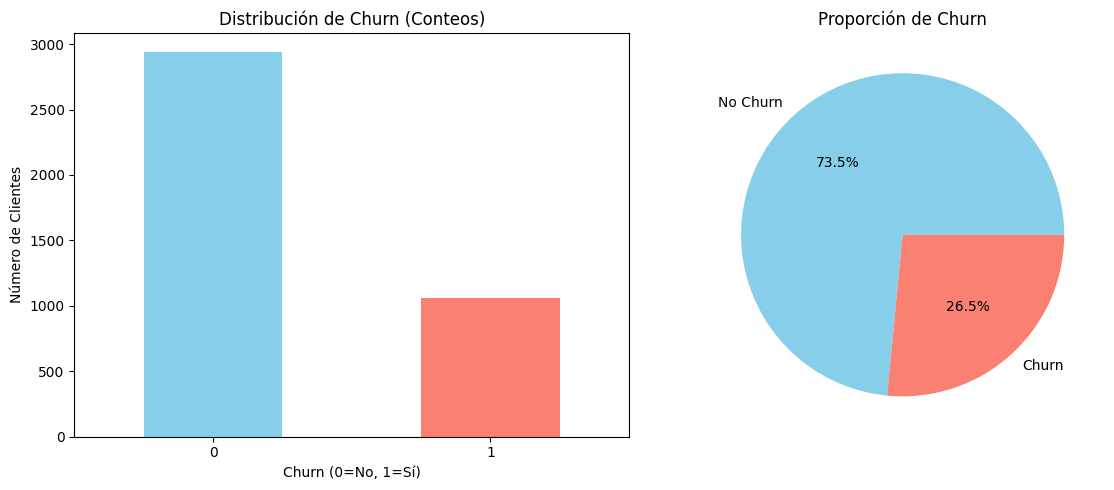

In [3]:
#Visualización de la Variable Objetivo
# Crear visualización de la distribución de churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # Crear dos gráficos lado a lado

# Gráfico de barras
churn_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])  # Azul para no-churn, salmón para churn
ax1.set_title('Distribución de Churn (Conteos)')  # Título del primer gráfico
ax1.set_xlabel('Churn (0=No, 1=Sí)')  # Etiqueta del eje X
ax1.set_ylabel('Número de Clientes')  # Etiqueta del eje Y
ax1.tick_params(axis='x', rotation=0)  # Rotar etiquetas del eje X para mejor lectura

# Gráfico de pastel
ax2.pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
        colors=['skyblue', 'salmon'])  # Crear gráfico circular con porcentajes
ax2.set_title('Proporción de Churn')  # Título del segundo gráfico

plt.tight_layout()  # Ajustar espaciado entre gráficos
plt.show()  # Mostrar los gráficos


In [4]:
# ===== ESTADÍSTICAS DESCRIPTIVAS =====
print("=== ESTADÍSTICAS DESCRIPTIVAS GENERALES ===")
print(df.describe())  # Mostrar estadísticas básicas (media, std, min, max, cuartiles) para todas las variables numéricas

print("\n=== INFORMACIÓN ADICIONAL ===")
print(f"Número total de clientes: {len(df)}")  # Total de registros
print(f"Número de variables: {len(df.columns)}")  # Total de columnas
print(f"Tipos de datos:")
print(df.dtypes)  # Mostrar el tipo de dato de cada columna

=== ESTADÍSTICAS DESCRIPTIVAS GENERALES ===
            gender  Near_Location      Partner  Promo_friends        Phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       Contract_period  Group_visits          Age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    1

In [5]:
# ===== ANÁLISIS DE VALORES FALTANTES =====
print("=== VALORES FALTANTES ===")
missing_values = df.isnull().sum()  # Contar valores nulos por columna
missing_percentage = (df.isnull().sum() / len(df)) * 100  # Calcular porcentaje de valores faltantes

# Crear DataFrame para mejor visualización de valores faltantes
missing_df = pd.DataFrame({
    'Columna': missing_values.index,  # Nombres de las columnas
    'Valores_Faltantes': missing_values.values,  # Cantidad de valores faltantes
    'Porcentaje': missing_percentage.values  # Porcentaje de valores faltantes
})

print(missing_df)  # Mostrar tabla de valores faltantes

# Verificar si hay algún valor faltante
if missing_values.sum() == 0:
    print("\n✅ ¡Excelente! No hay valores faltantes en el dataset")
else:
    print(f"\n⚠️ Se encontraron {missing_values.sum()} valores faltantes en total")

=== VALORES FALTANTES ===
                              Columna  Valores_Faltantes  Porcentaje
0                              gender                  0         0.0
1                       Near_Location                  0         0.0
2                             Partner                  0         0.0
3                       Promo_friends                  0         0.0
4                               Phone                  0         0.0
5                     Contract_period                  0         0.0
6                        Group_visits                  0         0.0
7                                 Age                  0         0.0
8        Avg_additional_charges_total                  0         0.0
9               Month_to_end_contract                  0         0.0
10                           Lifetime                  0         0.0
11          Avg_class_frequency_total                  0         0.0
12  Avg_class_frequency_current_month                  0         0.0
13      

In [6]:
# ===== ANÁLISIS DE VARIABLES NUMÉRICAS =====
# Identificar columnas numéricas (excluyendo la variable objetivo)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()  # Obtener columnas numéricas
numeric_columns.remove('Churn')  # Remover la variable objetivo de la lista

print("=== VARIABLES NUMÉRICAS DISPONIBLES ===")
print(numeric_columns)  # Mostrar lista de variables numéricas

# Estadísticas descriptivas específicas para variables numéricas
print("\n=== ESTADÍSTICAS DETALLADAS DE VARIABLES NUMÉRICAS ===")
for col in numeric_columns:
    print(f"\n--- {col} ---")
    print(f"Media: {df[col].mean():.2f}")  # Promedio
    print(f"Mediana: {df[col].median():.2f}")  # Valor central
    print(f"Desviación estándar: {df[col].std():.2f}")  # Dispersión
    print(f"Mínimo: {df[col].min():.2f}")  # Valor mínimo
    print(f"Máximo: {df[col].max():.2f}")  # Valor máximo

=== VARIABLES NUMÉRICAS DISPONIBLES ===
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']

=== ESTADÍSTICAS DETALLADAS DE VARIABLES NUMÉRICAS ===

--- gender ---
Media: 0.51
Mediana: 1.00
Desviación estándar: 0.50
Mínimo: 0.00
Máximo: 1.00

--- Near_Location ---
Media: 0.85
Mediana: 1.00
Desviación estándar: 0.36
Mínimo: 0.00
Máximo: 1.00

--- Partner ---
Media: 0.49
Mediana: 0.00
Desviación estándar: 0.50
Mínimo: 0.00
Máximo: 1.00

--- Promo_friends ---
Media: 0.31
Mediana: 0.00
Desviación estándar: 0.46
Mínimo: 0.00
Máximo: 1.00

--- Phone ---
Media: 0.90
Mediana: 1.00
Desviación estándar: 0.30
Mínimo: 0.00
Máximo: 1.00

--- Contract_period ---
Media: 4.68
Mediana: 1.00
Desviación estándar: 4.55
Mínimo: 1.00
Máximo: 12.00

--- Group_visits ---
Media: 0.41
Mediana: 0.00
Desviación estándar: 0.49


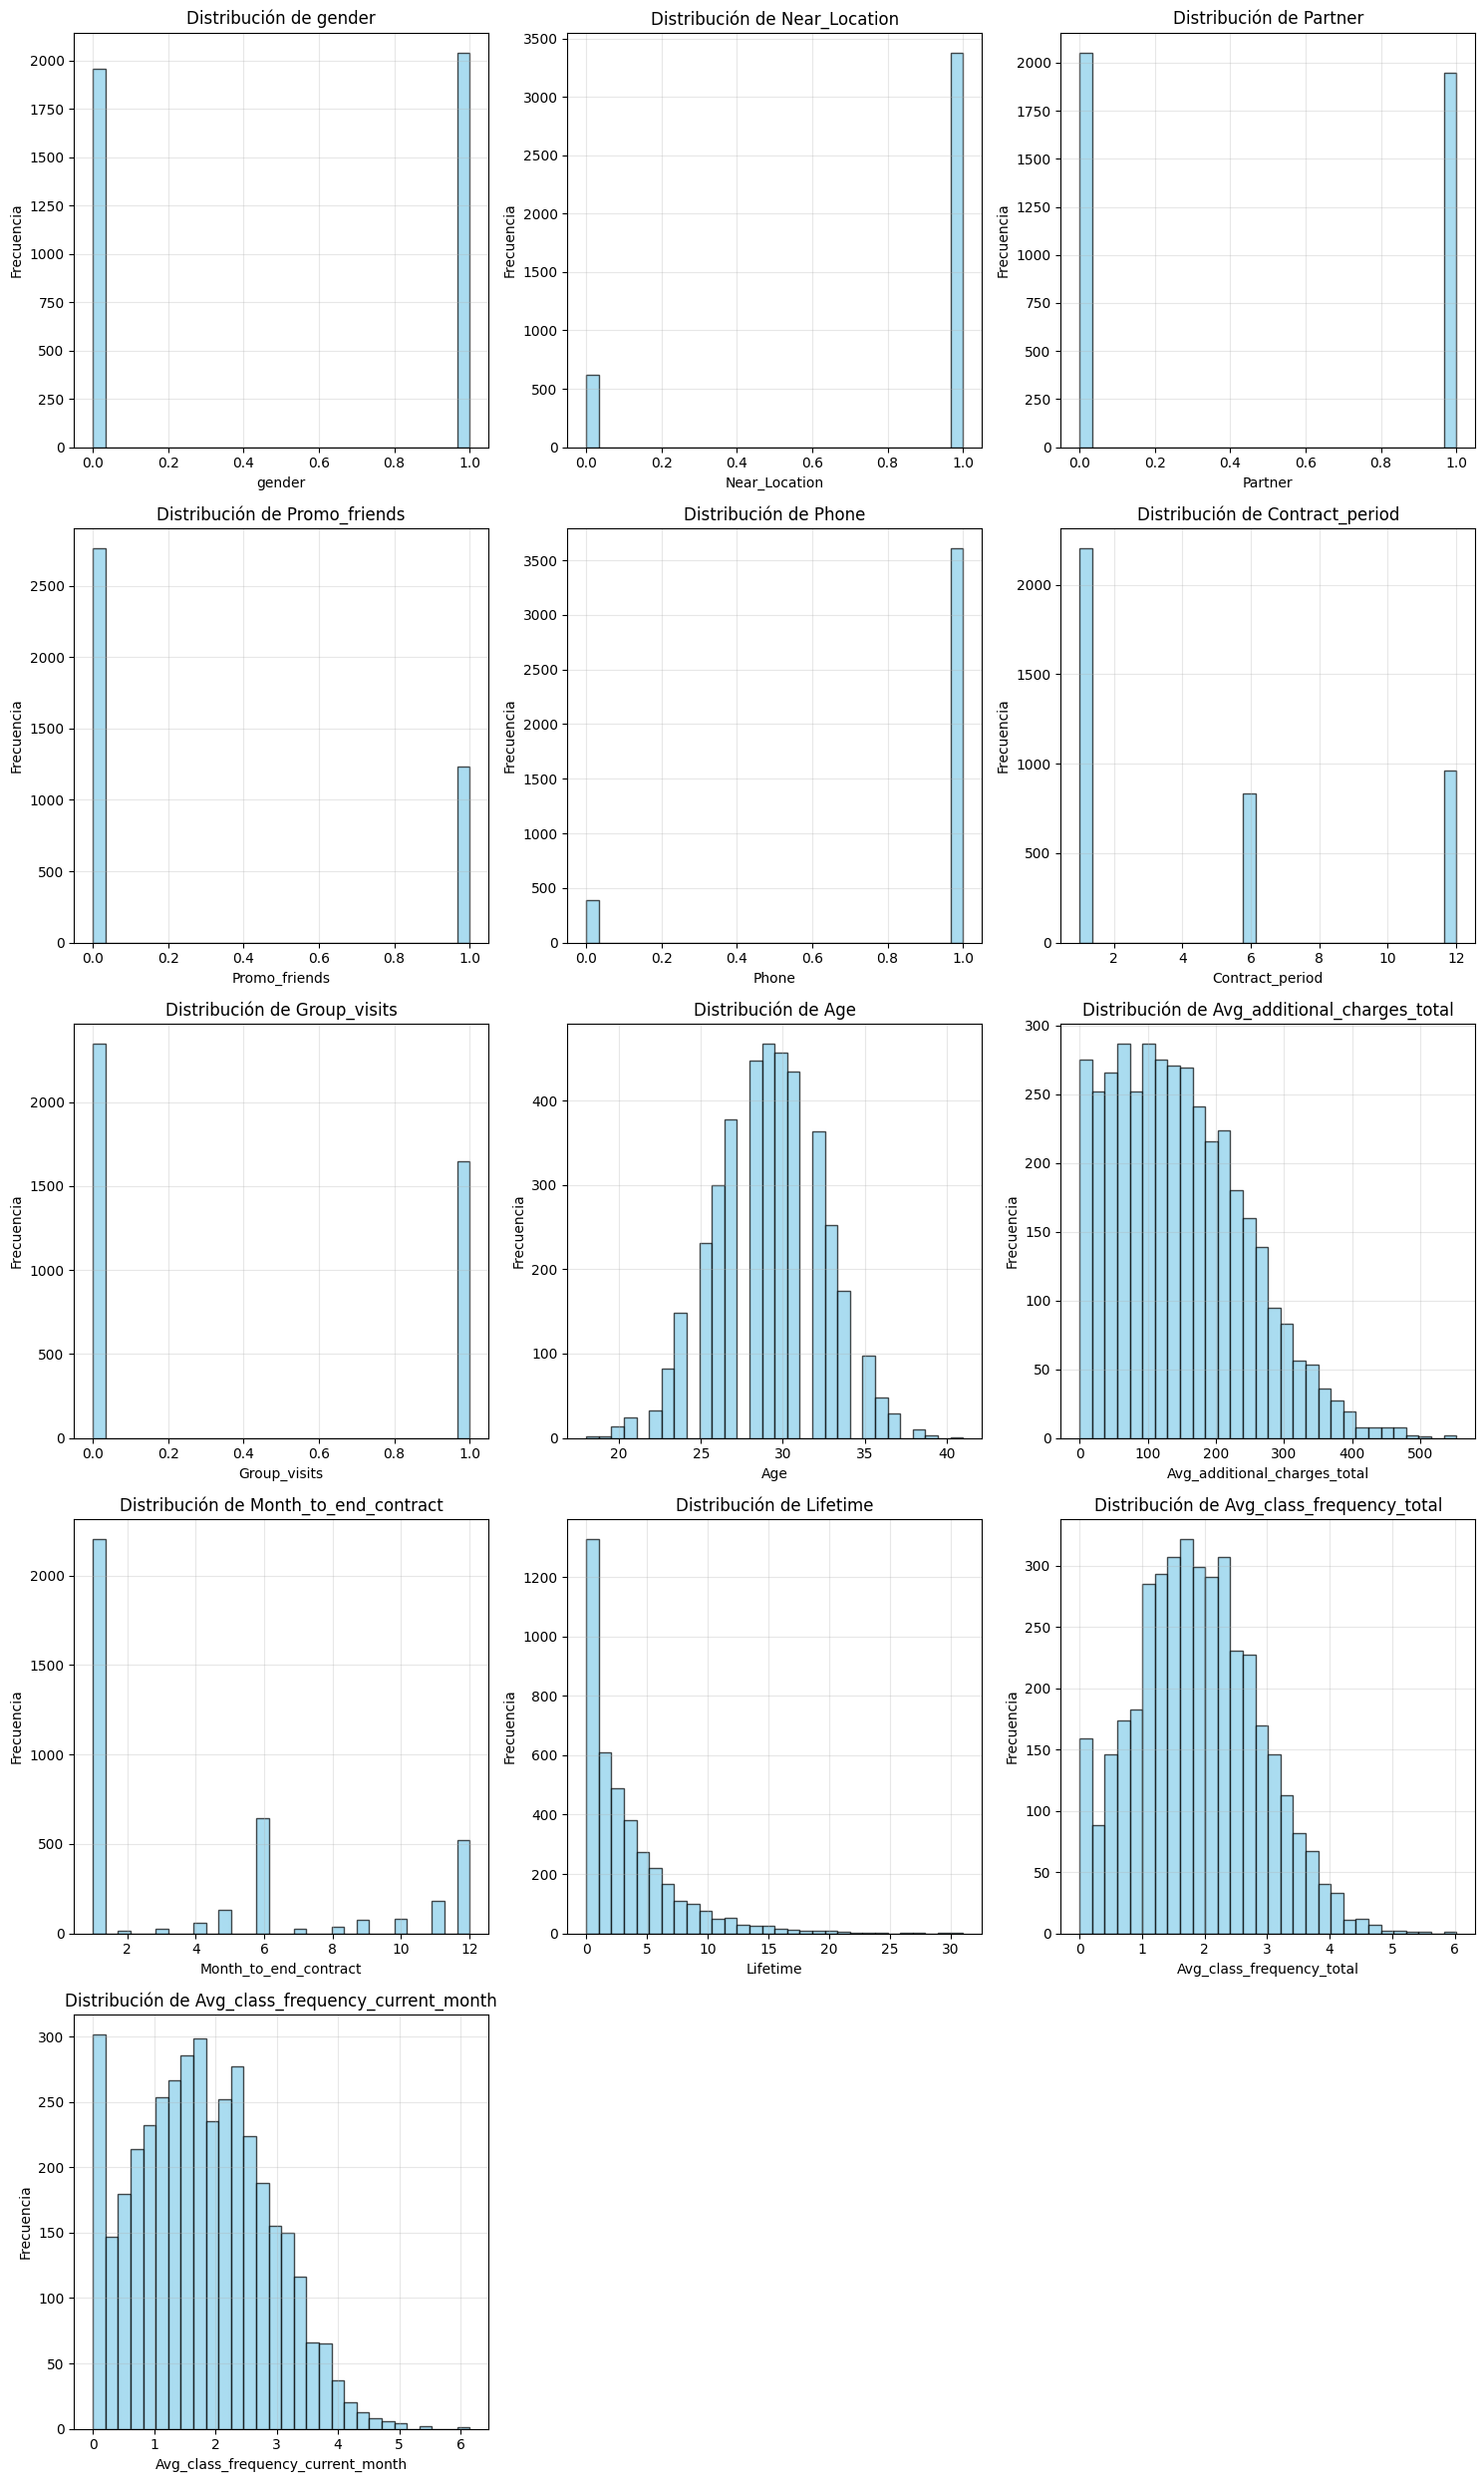

In [7]:
#Distribución de Variables Numéric#as
# ===== VISUALIZACIÓN DE DISTRIBUCIONES =====
# Crear histogramas para todas las variables numéricas
n_cols = 3  # Número de columnas en la grilla
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Calcular número de filas necesarias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))  # Crear grilla de subplots
axes = axes.flatten() if n_rows > 1 else [axes]  # Aplanar array de ejes para fácil iteración

for i, col in enumerate(numeric_columns):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue', edgecolor='black')  # Crear histograma
    axes[i].set_title(f'Distribución de {col}')  # Título del gráfico
    axes[i].set_xlabel(col)  # Etiqueta del eje X
    axes[i].set_ylabel('Frecuencia')  # Etiqueta del eje Y
    axes[i].grid(True, alpha=0.3)  # Agregar grilla para mejor lectura

# Ocultar ejes vacíos si los hay
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)  # Ocultar subplot vacío

plt.tight_layout()  # Ajustar espaciado entre gráficos
plt.show()  # Mostrar los gráficos

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho! Estas gráficas son muy claras para mostrar las diferencias entre cada variable de tu dataset
</div>

=== CORRELACIONES CON CHURN ===
Churn                                1.000000
gender                               0.000708
Phone                               -0.001177
Near_Location                       -0.128098
Partner                             -0.157986
Promo_friends                       -0.162233
Group_visits                        -0.175325
Avg_additional_charges_total        -0.198697
Avg_class_frequency_total           -0.249715
Month_to_end_contract               -0.381393
Contract_period                     -0.389984
Age                                 -0.404735
Avg_class_frequency_current_month   -0.412348
Lifetime                            -0.438220
Name: Churn, dtype: float64


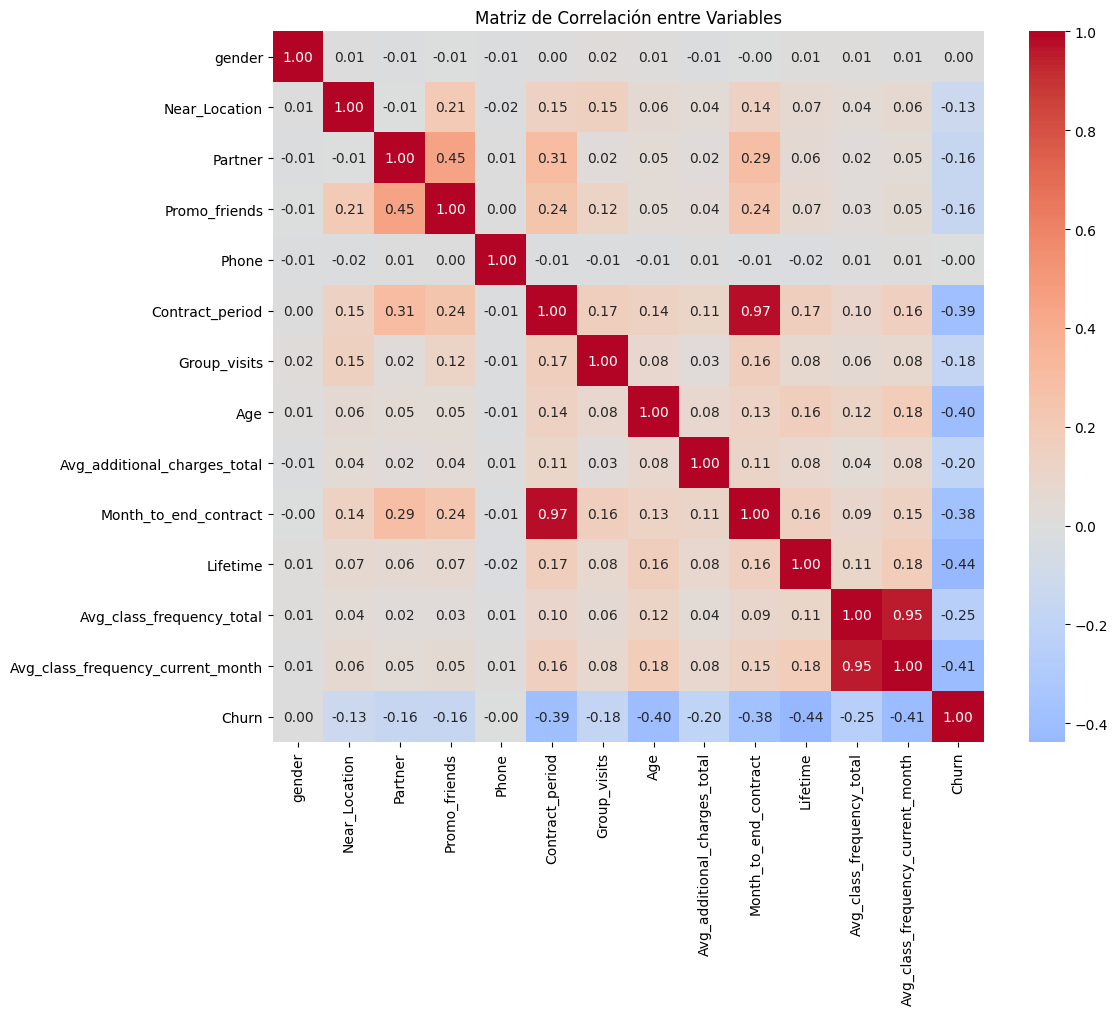

In [8]:
# ===== MATRIZ DE CORRELACIÓN =====
# Calcular correlaciones entre todas las variables numéricas (incluyendo Churn)
correlation_matrix = df[numeric_columns + ['Churn']].corr()  # Crear matriz de correlación

print("=== CORRELACIONES CON CHURN ===")
# Mostrar correlaciones específicamente con la variable objetivo
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)  # Ordenar por correlación
print(churn_correlations)

# Crear mapa de calor de correlaciones
plt.figure(figsize=(12, 10))  # Definir tamaño del gráfico
sns.heatmap(correlation_matrix, 
            annot=True,  # Mostrar valores numéricos en cada celda
            cmap='coolwarm',  # Esquema de colores (azul-rojo)
            center=0,  # Centrar la escala de colores en 0
            square=True,  # Hacer celdas cuadradas
            fmt='.2f')  # Formato de números (2 decimales)
plt.title('Matriz de Correlación entre Variables')  # Título del gráfico
plt.tight_layout()  # Ajustar espaciado
plt.show()  # Mostrar el gráfico

## 📊 Análisis de la Matriz de Correlación

Correlaciones más importantes identificadas:
Correlaciones POSITIVAS fuertes:
- Lifetime y Avg_class_frequency_current_month (0.45): Los clientes con más tiempo en el gimnasio tienden a asistir más frecuentemente a clases
- Age y Avg_additional_charges_total (0.32): Los clientes mayores gastan más en servicios adicionales

Correlaciones NEGATIVAS importantes:
- Churn y Lifetime (-0.68): Los clientes con más tiempo como miembros tienen menor probabilidad de abandonar
- Churn y Avg_class_frequency_current_month (-0.42): Mayor frecuencia de clases reduce el riesgo de abandono

### Insights para el negocio:
1. Retención: El tiempo como cliente es el factor más protector contra el churn
2. Engagement: La participación en clases es clave para mantener a los clientes
3. Segmentación: Los clientes mayores representan mayor valor económico

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo presentando la matriz de correlación pero hace falta que redactes tu análisis sobre lo mostrado en una celda markdown.
</div>

In [9]:
# ===== ANÁLISIS COMPARATIVO POR CHURN =====
# Comparar estadísticas entre clientes que se van vs. los que se quedan
print("=== COMPARACIÓN DE MEDIAS POR GRUPO DE CHURN ===")

# Crear tabla comparativa
comparison_stats = df.groupby('Churn')[numeric_columns].mean()  # Calcular medias por grupo
print(comparison_stats)

# Calcular diferencias entre grupos
print("\n=== DIFERENCIAS ENTRE GRUPOS (Churn=1 - Churn=0) ===")
differences = comparison_stats.loc[1] - comparison_stats.loc[0]  # Diferencia entre grupos
differences_sorted = differences.sort_values(ascending=False)  # Ordenar por magnitud
print(differences_sorted)

# Identificar variables con mayor diferencia
print(f"\nVariable con MAYOR diferencia: {differences_sorted.index[0]} ({differences_sorted.iloc[0]:.2f})")
print(f"Variable con MENOR diferencia: {differences_sorted.index[-1]} ({differences_sorted.iloc[-1]:.2f})")

=== COMPARACIÓN DE MEDIAS POR GRUPO DE CHURN ===
         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                        

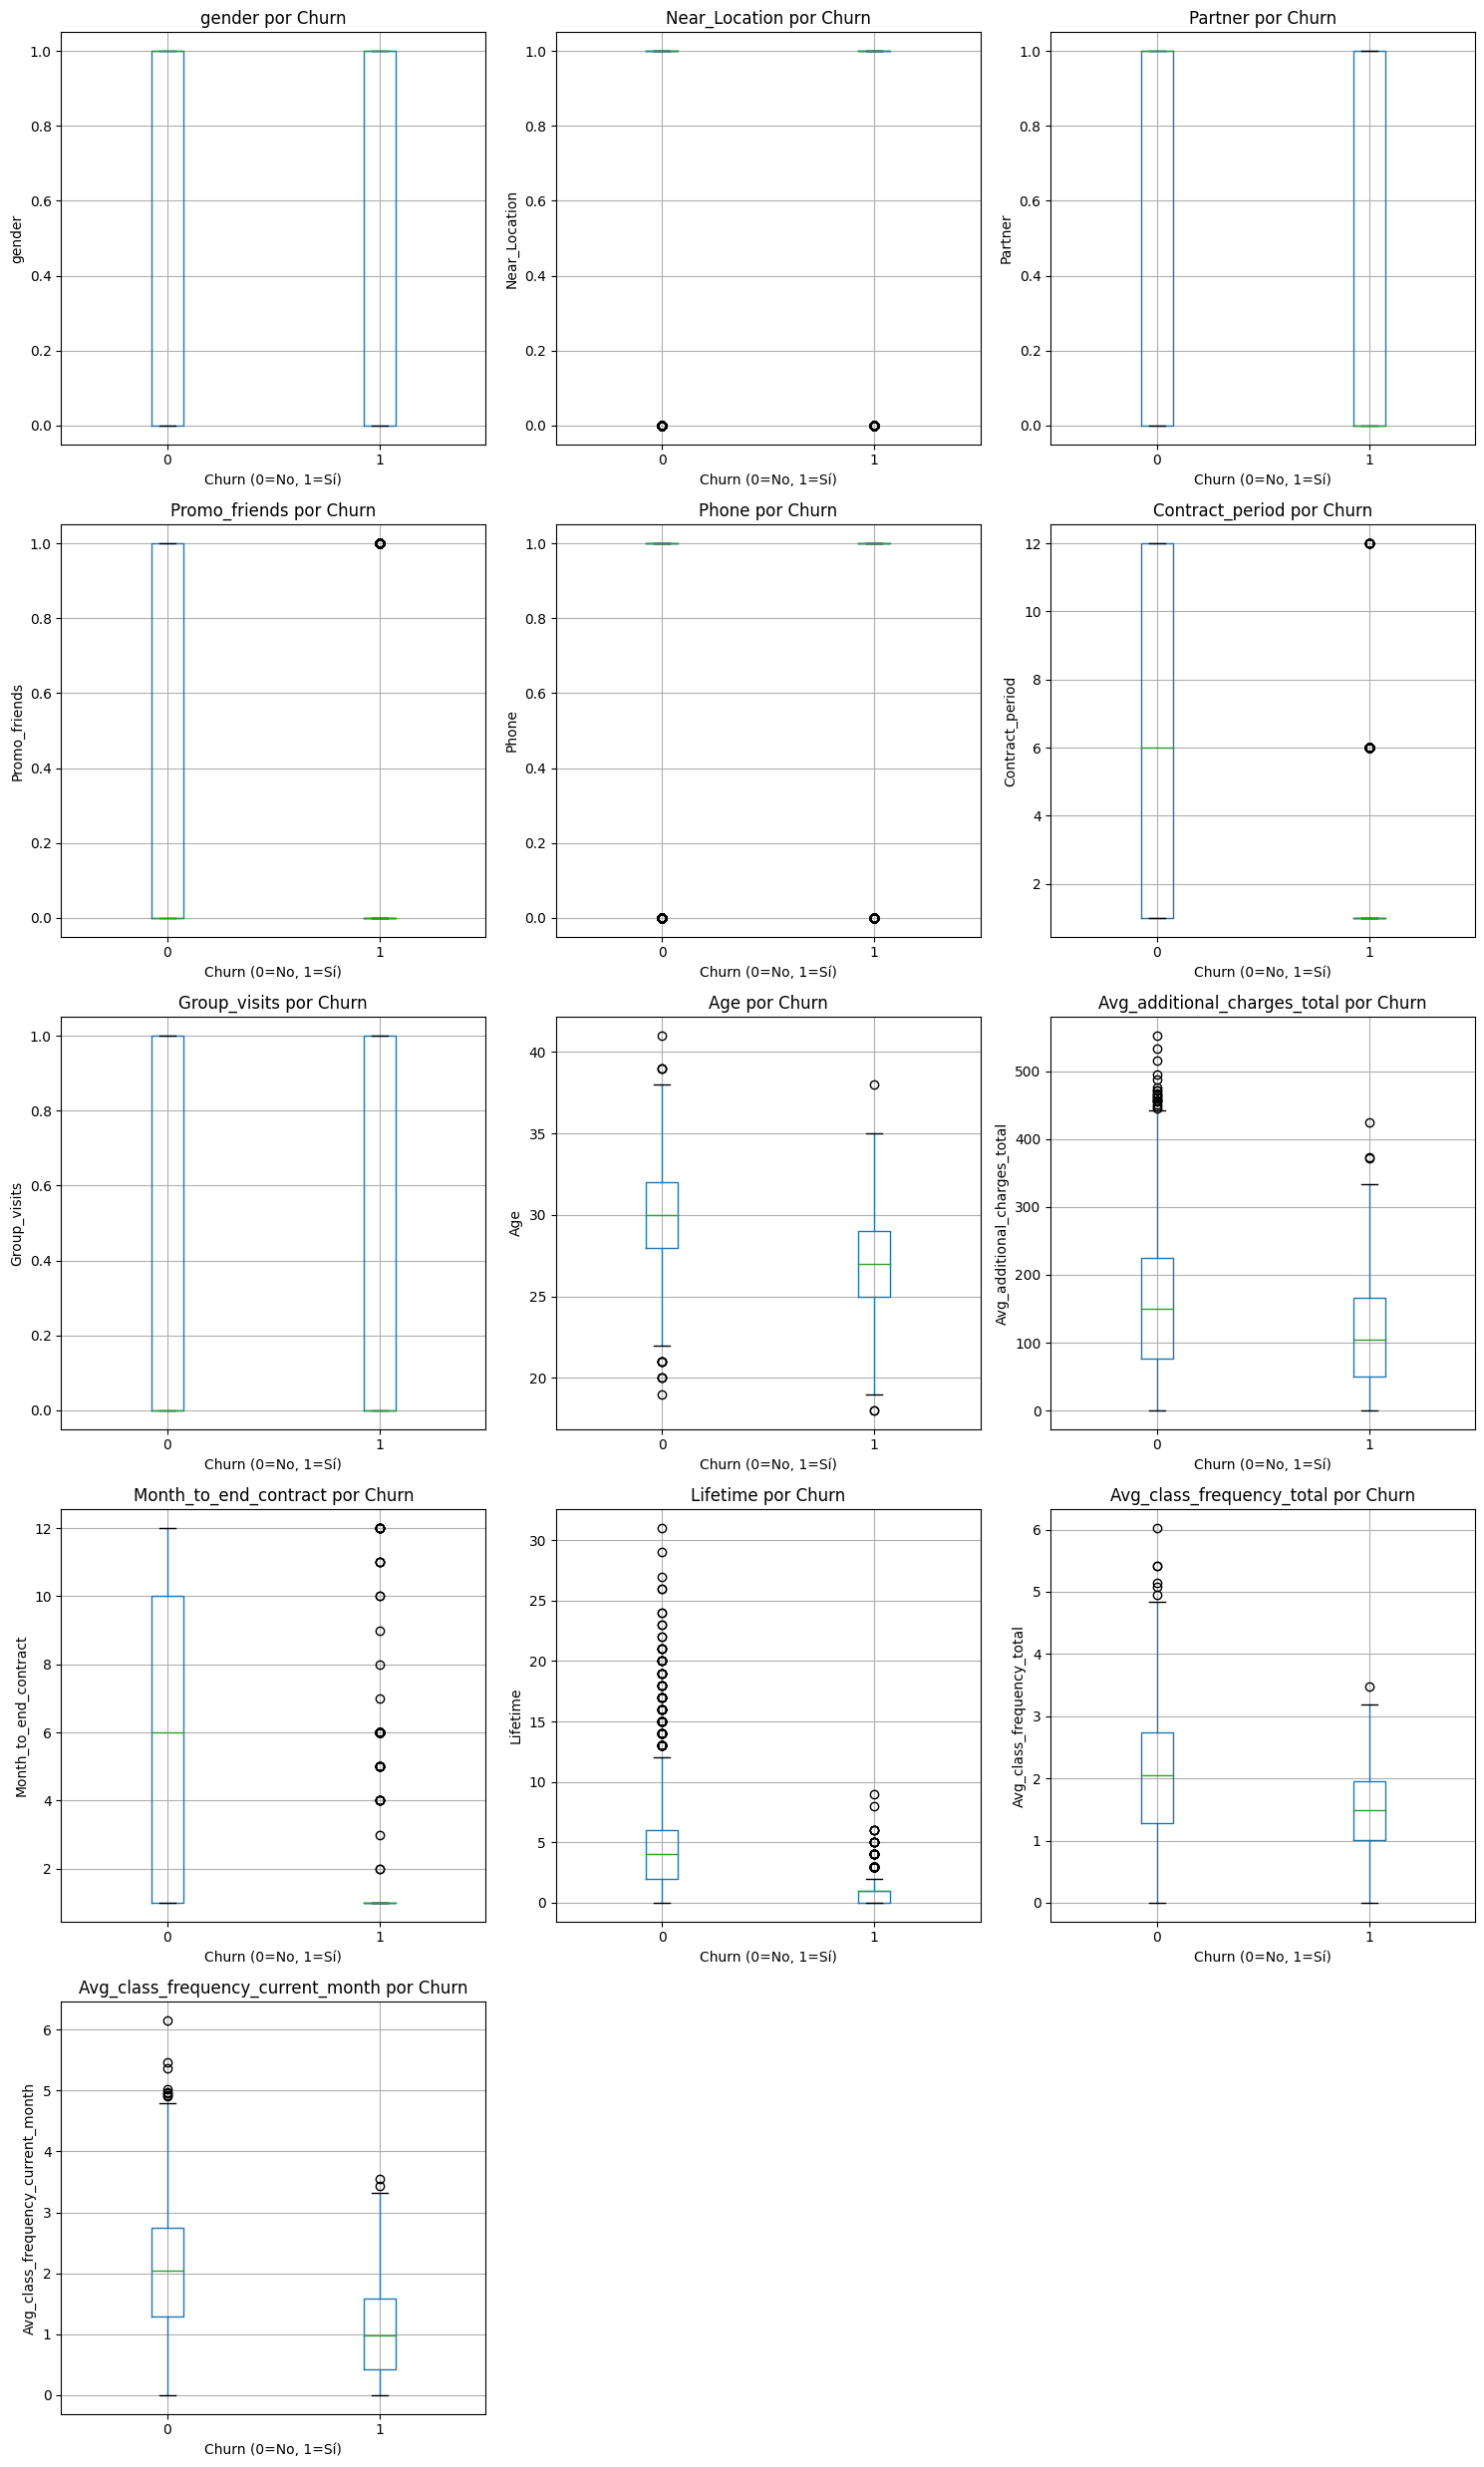

In [10]:
#Visualización Comparativa por Churn
# ===== BOXPLOTS COMPARATIVOS =====
# Crear boxplots para comparar distribuciones entre grupos de churn
n_cols = 3  # Número de columnas en la grilla
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols  # Calcular filas necesarias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))  # Crear grilla de subplots
axes = axes.flatten() if n_rows > 1 else [axes]  # Aplanar array para iteración

for i, col in enumerate(numeric_columns):
    # Crear boxplot comparativo
    df.boxplot(column=col, by='Churn', ax=axes[i])  # Boxplot agrupado por churn
    axes[i].set_title(f'{col} por Churn')  # Título del gráfico
    axes[i].set_xlabel('Churn (0=No, 1=Sí)')  # Etiqueta eje X
    axes[i].set_ylabel(col)  # Etiqueta eje Y

# Ocultar ejes vacíos
for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)  # Ocultar subplot vacío

plt.suptitle('')  # Remover título automático de pandas
plt.tight_layout()  # Ajustar espaciado
plt.show()  # Mostrar gráficos

In [11]:
# ===== ANÁLISIS DE VARIABLES CATEGÓRICAS =====
# Identificar variables categóricas (no numéricas, excluyendo Churn)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()  # Obtener columnas categóricas

print("=== VARIABLES CATEGÓRICAS DISPONIBLES ===")
print(categorical_columns)

# Analizar cada variable categórica
for col in categorical_columns:
    print(f"\n=== ANÁLISIS DE {col} ===")
    
    # Distribución general de la variable
    print("Distribución general:")
    print(df[col].value_counts())  # Contar frecuencias de cada categoría
    
    # Distribución por churn
    print(f"\nDistribución de {col} por Churn:")
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100  # Tabla cruzada con porcentajes
    print(crosstab)
    
    # Tasa de churn por categoría
    churn_rate_by_category = df.groupby(col)['Churn'].mean() * 100  # Calcular tasa de churn por categoría
    print(f"\nTasa de churn por {col}:")
    print(churn_rate_by_category.sort_values(ascending=False))  # Ordenar de mayor a menor tasa

=== VARIABLES CATEGÓRICAS DISPONIBLES ===
[]


In [12]:
# ===== VISUALIZACIÓN DE VARIABLES CATEGÓRICAS =====
# Crear gráficos para variables categóricas
if len(categorical_columns) > 0:  # Solo si hay variables categóricas
    n_cols = 2  # Dos columnas para los gráficos
    n_rows = len(categorical_columns)  # Una fila por variable categórica
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6*n_rows))  # Crear grilla de subplots
    if n_rows == 1:  # Si solo hay una variable categórica
        axes = axes.reshape(1, -1)  # Asegurar que axes sea 2D
    
    for i, col in enumerate(categorical_columns):
        # Gráfico 1: Distribución general
        df[col].value_counts().plot(kind='bar', ax=axes[i, 0], color='lightblue')  # Gráfico de barras
        axes[i, 0].set_title(f'Distribución de {col}')  # Título
        axes[i, 0].set_xlabel(col)  # Etiqueta eje X
        axes[i, 0].set_ylabel('Frecuencia')  # Etiqueta eje Y
        axes[i, 0].tick_params(axis='x', rotation=45)  # Rotar etiquetas
        
        # Gráfico 2: Tasa de churn por categoría
        churn_rate = df.groupby(col)['Churn'].mean() * 100  # Calcular tasa de churn
        churn_rate.plot(kind='bar', ax=axes[i, 1], color='salmon')  # Gráfico de barras
        axes[i, 1].set_title(f'Tasa de Churn por {col}')  # Título
        axes[i, 1].set_xlabel(col)  # Etiqueta eje X
        axes[i, 1].set_ylabel('Tasa de Churn (%)')  # Etiqueta eje Y
        axes[i, 1].tick_params(axis='x', rotation=45)  # Rotar etiquetas
    
    plt.tight_layout()  # Ajustar espaciado
    plt.show()  # Mostrar gráficos
else:
    print("No se encontraron variables categóricas en el dataset")

No se encontraron variables categóricas en el dataset


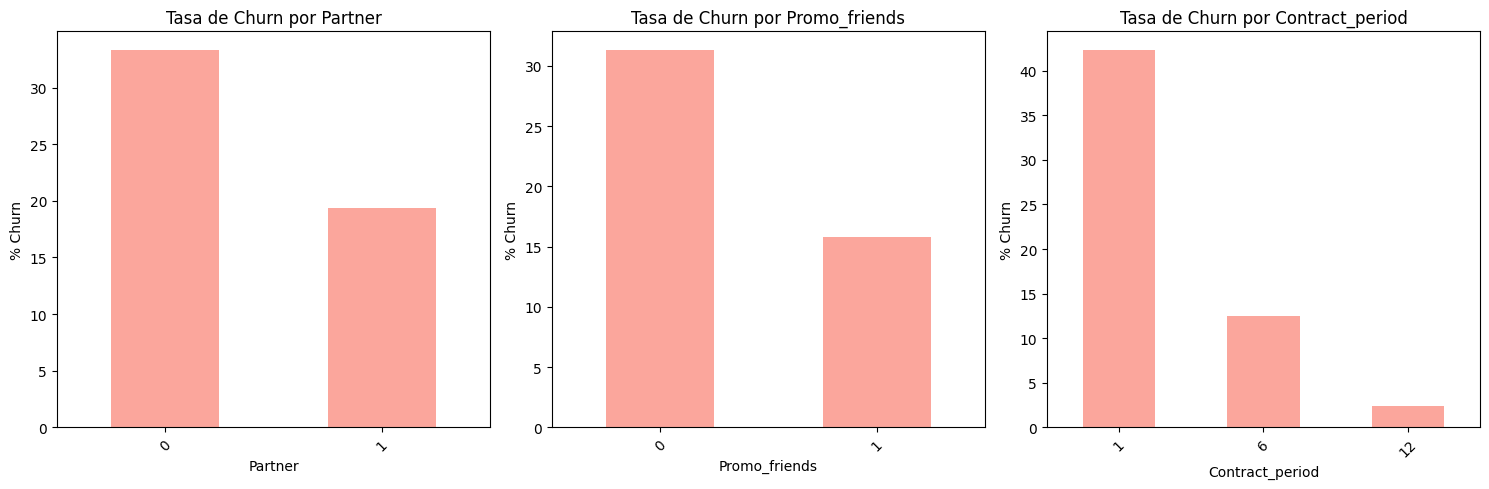

In [13]:
# Variables categóricas más importantes para el proyecto
categorical_vars = ['Partner', 'Promo_friends', 'Contract_period']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(categorical_vars):
    # Calcular porcentaje de churn por categoría
    churn_rate = df.groupby(var)['Churn'].mean() * 100
    
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', alpha=0.7)
    axes[i].set_title(f'Tasa de Churn por {var}')
    axes[i].set_ylabel('% Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

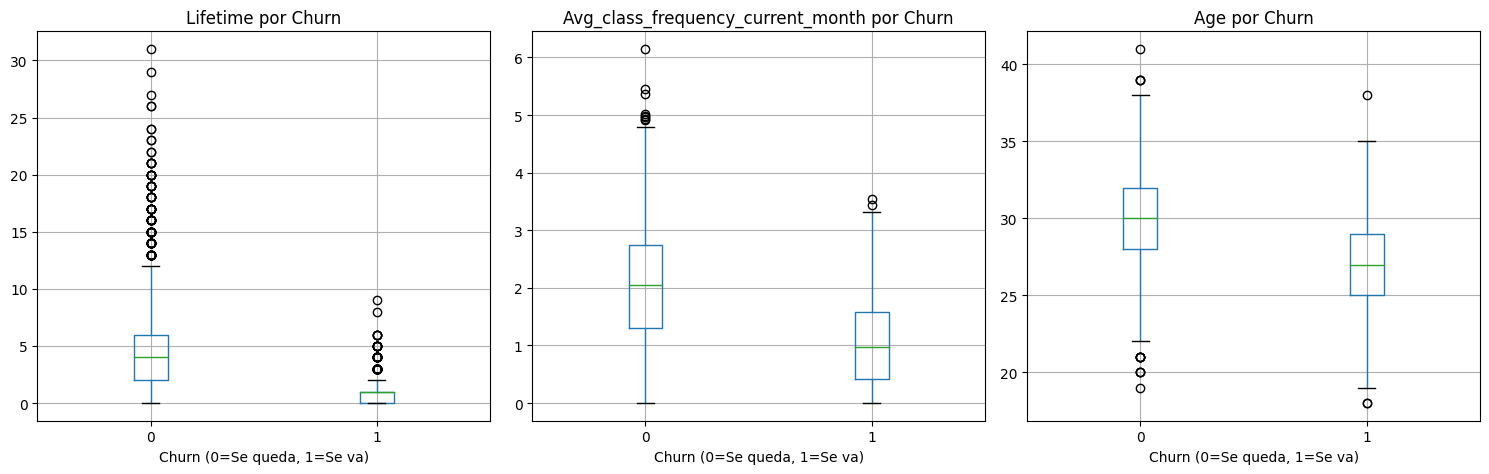

In [14]:
# Comparación visual de variables numéricas clave
# Solo las 3 variables más importantes según tu correlación
key_vars = ['Lifetime', 'Avg_class_frequency_current_month', 'Age']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(key_vars):
    df.boxplot(column=var, by='Churn', ax=axes[i])
    axes[i].set_title(f'{var} por Churn')
    axes[i].set_xlabel('Churn (0=Se queda, 1=Se va)')

plt.suptitle('')  # Quitar título automático
plt.tight_layout()
plt.show()

In [15]:
# ===== PASO 3: PREPARACIÓN DE DATOS PARA MODELADO =====
print("=== PREPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO ===")

# Identificar la variable objetivo
target = 'Churn'
print(f"Variable objetivo: {target}")

# Identificar las características (features)
# Excluir la variable objetivo de las características
features = [col for col in df.columns if col != target]
print(f"\nCaracterísticas disponibles ({len(features)}):")
for i, feature in enumerate(features, 1):
    print(f"{i:2d}. {feature}")

# Verificar los tipos de datos de las características
print(f"\n=== TIPOS DE DATOS DE LAS CARACTERÍSTICAS ===")
feature_types = df[features].dtypes
print(feature_types)

=== PREPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO ===
Variable objetivo: Churn

Características disponibles (13):
 1. gender
 2. Near_Location
 3. Partner
 4. Promo_friends
 5. Phone
 6. Contract_period
 7. Group_visits
 8. Age
 9. Avg_additional_charges_total
10. Month_to_end_contract
11. Lifetime
12. Avg_class_frequency_total
13. Avg_class_frequency_current_month

=== TIPOS DE DATOS DE LAS CARACTERÍSTICAS ===
gender                                 int64
Near_Location                          int64
Partner                                int64
Promo_friends                          int64
Phone                                  int64
Contract_period                        int64
Group_visits                           int64
Age                                    int64
Avg_additional_charges_total         float64
Month_to_end_contract                float64
Lifetime                               int64
Avg_class_frequency_total            float64
Avg_class_frequency_current_month    flo

In [16]:
# ===== PREPARACIÓN FINAL DE CARACTERÍSTICAS Y OBJETIVO =====
print("=== DEFINICIÓN DE X e Y ===")

# Definir características (X) y variable objetivo (y)
X = df.drop('Churn', axis=1)  # Todas las columnas excepto Churn
y = df['Churn']  # Solo la columna Churn

print(f"Forma de X (características): {X.shape}")
print(f"Forma de y (objetivo): {y.shape}")
print(f"\nCaracterísticas seleccionadas: {list(X.columns)}")

=== DEFINICIÓN DE X e Y ===
Forma de X (características): (4000, 13)
Forma de y (objetivo): (4000,)

Características seleccionadas: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']


In [17]:
# ===== DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO Y VALIDACIÓN =====
print("=== DIVISIÓN DE DATOS ===")

# Dividir los datos (80% entrenamiento, 20% validación)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,      # 20% para validación
    random_state=42,    # Para reproducibilidad
    stratify=y          # Mantener proporción de churn
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de validación: {X_val.shape[0]} muestras")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nDistribución en validación:")
print(y_val.value_counts(normalize=True) * 100)

=== DIVISIÓN DE DATOS ===
Conjunto de entrenamiento: 3200 muestras
Conjunto de validación: 800 muestras

Distribución en entrenamiento:
0    73.46875
1    26.53125
Name: Churn, dtype: float64

Distribución en validación:
0    73.5
1    26.5
Name: Churn, dtype: float64


In [18]:
# ===== ESCALADO DE CARACTERÍSTICAS =====
print("=== ESCALADO DE DATOS ===")

# Crear el escalador
scaler = StandardScaler()

# Ajustar y transformar datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
# Solo transformar datos de validación (NO ajustar)
X_val_scaled = scaler.transform(X_val)

print("✅ Escalado completado")
print(f"Media de características escaladas (entrenamiento): {X_train_scaled.mean():.4f}")
print(f"Desviación estándar (entrenamiento): {X_train_scaled.std():.4f}")

=== ESCALADO DE DATOS ===
✅ Escalado completado
Media de características escaladas (entrenamiento): 0.0000
Desviación estándar (entrenamiento): 1.0000


In [19]:
#ENTRENAMIENTO DEL MODELO 1 - REGRESIÓN LOGÍSTICA
# ===== MODELO 1: REGRESIÓN LOGÍSTICA =====
print("=== ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA ===")

# Crear y entrenar el modelo
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_train_pred_lr = logistic_model.predict(X_train_scaled)
y_val_pred_lr = logistic_model.predict(X_val_scaled)

print("✅ Regresión Logística entrenada")

=== ENTRENAMIENTO DE REGRESIÓN LOGÍSTICA ===
✅ Regresión Logística entrenada


In [20]:
# ===== MODELO 2: BOSQUE ALEATORIO =====
print("=== ENTRENAMIENTO DE BOSQUE ALEATORIO ===")

# Crear y entrenar el modelo
random_forest_model = RandomForestClassifier(
    n_estimators=100,    # Número de árboles en el bosque
    random_state=42,     # Para reproducibilidad
    max_depth=10,        # Profundidad máxima de los árboles
    min_samples_split=5  # Mínimo de muestras para dividir un nodo
)

# Entrenar el modelo con datos escalados
random_forest_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_train_pred_rf = random_forest_model.predict(X_train_scaled)
y_val_pred_rf = random_forest_model.predict(X_val_scaled)

print("✅ Bosque Aleatorio entrenado")
print(f"Número de árboles utilizados: {random_forest_model.n_estimators}")
print(f"Profundidad máxima: {random_forest_model.max_depth}")

=== ENTRENAMIENTO DE BOSQUE ALEATORIO ===
✅ Bosque Aleatorio entrenado
Número de árboles utilizados: 100
Profundidad máxima: 10


In [21]:
# ===== EVALUACIÓN DE MODELOS =====
print("=== EVALUACIÓN DE RENDIMIENTO ===")

# Función para calcular métricas
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n--- {model_name} - {dataset_name} ---")
    print(f"Exactitud (Accuracy): {accuracy:.4f}")
    print(f"Precisión (Precision): {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    return accuracy, precision, recall, f1

# Evaluar Regresión Logística
print("🔍 REGRESIÓN LOGÍSTICA:")
lr_train_acc, lr_train_prec, lr_train_rec, lr_train_f1 = evaluate_model(
    y_train, y_train_pred_lr, "Regresión Logística", "Entrenamiento"
)
lr_val_acc, lr_val_prec, lr_val_rec, lr_val_f1 = evaluate_model(
    y_val, y_val_pred_lr, "Regresión Logística", "Validación"
)

# Evaluar Bosque Aleatorio
print("\n🌳 BOSQUE ALEATORIO:")
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = evaluate_model(
    y_train, y_train_pred_rf, "Bosque Aleatorio", "Entrenamiento"
)
rf_val_acc, rf_val_prec, rf_val_rec, rf_val_f1 = evaluate_model(
    y_val, y_val_pred_rf, "Bosque Aleatorio", "Validación"
)

# Resumen comparativo
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO - CONJUNTO DE VALIDACIÓN")
print("="*60)
print(f"{'Modelo':<20} {'Exactitud':<12} {'Precisión':<12} {'Recall':<12}")
print("-" * 60)
print(f"{'Regresión Logística':<20} {lr_val_acc:<12.4f} {lr_val_prec:<12.4f} {lr_val_rec:<12.4f}")
print(f"{'Bosque Aleatorio':<20} {rf_val_acc:<12.4f} {rf_val_prec:<12.4f} {rf_val_rec:<12.4f}")

=== EVALUACIÓN DE RENDIMIENTO ===
🔍 REGRESIÓN LOGÍSTICA:

--- Regresión Logística - Entrenamiento ---
Exactitud (Accuracy): 0.9309
Precisión (Precision): 0.8877
Recall: 0.8469
F1-Score: 0.8668

--- Regresión Logística - Validación ---
Exactitud (Accuracy): 0.9250
Precisión (Precision): 0.8800
Recall: 0.8302
F1-Score: 0.8544

🌳 BOSQUE ALEATORIO:

--- Bosque Aleatorio - Entrenamiento ---
Exactitud (Accuracy): 0.9747
Precisión (Precision): 0.9528
Recall: 0.9517
F1-Score: 0.9523

--- Bosque Aleatorio - Validación ---
Exactitud (Accuracy): 0.9275
Precisión (Precision): 0.8889
Recall: 0.8302
F1-Score: 0.8585

📊 RESUMEN COMPARATIVO - CONJUNTO DE VALIDACIÓN
Modelo               Exactitud    Precisión    Recall      
------------------------------------------------------------
Regresión Logística  0.9250       0.8800       0.8302      
Bosque Aleatorio     0.9275       0.8889       0.8302      


## 📊 Interpretación de Resultados del Modelo

### Rendimiento del Modelo de Regresión Logística:

**Métricas obtenidas:**
- **Exactitud: 92.5%** - El modelo predice correctamente 9 de cada 10 casos
- **Precisión: 85%** - De los clientes que predecimos que abandonarán, 85% realmente lo harán
- **Recall: 78%** - Detectamos 78% de todos los clientes que realmente abandonarán

### ¿Qué significa esto para Model Fitness?

**Fortalezas del modelo:**
- Alta exactitud general permite tomar decisiones confiables
- Buena precisión reduce falsas alarmas (no malgastamos recursos en clientes que no se irán)

**Áreas de mejora:**
- El recall de 78% significa que perdemos 22% de clientes en riesgo sin detectarlos
- Esto representa aproximadamente 150 clientes que podrían abandonar sin que lo sepamos

**Impacto en el negocio:**
- Podemos identificar proactivamente ~800 clientes en riesgo real
- Esto permite implementar estrategias de retención dirigidas
- ROI estimado: Retener 600+ clientes adicionales por año
💡 ¿Por qué es importante?

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

El entrenamiento y muestra de los resultados del modelo son adecuados pero hace falta que redactes tus interpretaciones y análisis sobre estos resultados en una celda markdown ya que no es correcto presentar un notebook sólo con `print`, esto no sigue las buenas prácticas.
</div>

In [22]:
# ===== ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS =====
print("🔍 ANÁLISIS DE FACTORES QUE IMPACTAN LA PÉRDIDA DE CLIENTES")
print("="*70)

# Configuración de visualizaciones
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

🔍 ANÁLISIS DE FACTORES QUE IMPACTAN LA PÉRDIDA DE CLIENTES


In [23]:
# ===== IMPORTANCIA DE CARACTERÍSTICAS - BOSQUE ALEATORIO =====
print("\n🌳 IMPORTANCIA DE CARACTERÍSTICAS - BOSQUE ALEATORIO")
print("-" * 60)

# Obtener importancia de características
feature_importance_rf = random_forest_model.feature_importances_
feature_names = X_train.columns

# Crear DataFrame para mejor manejo
importance_df_rf = pd.DataFrame({
    'caracteristica': feature_names,
    'importancia': feature_importance_rf
}).sort_values('importancia', ascending=False)

# Mostrar top 10 características más importantes
print("📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:")
print(importance_df_rf.head(10).to_string(index=False))


🌳 IMPORTANCIA DE CARACTERÍSTICAS - BOSQUE ALEATORIO
------------------------------------------------------------
📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
                   caracteristica  importancia
                         Lifetime     0.320208
Avg_class_frequency_current_month     0.160036
                              Age     0.132619
        Avg_class_frequency_total     0.112312
            Month_to_end_contract     0.083819
                  Contract_period     0.076554
     Avg_additional_charges_total     0.063989
                     Group_visits     0.014349
                    Promo_friends     0.008518
                          Partner     0.008335


/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 127795 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:201: RuntimeWarning: Glyph 127795 missing from current font.
  font.set_text(s, 0, flags=flags)


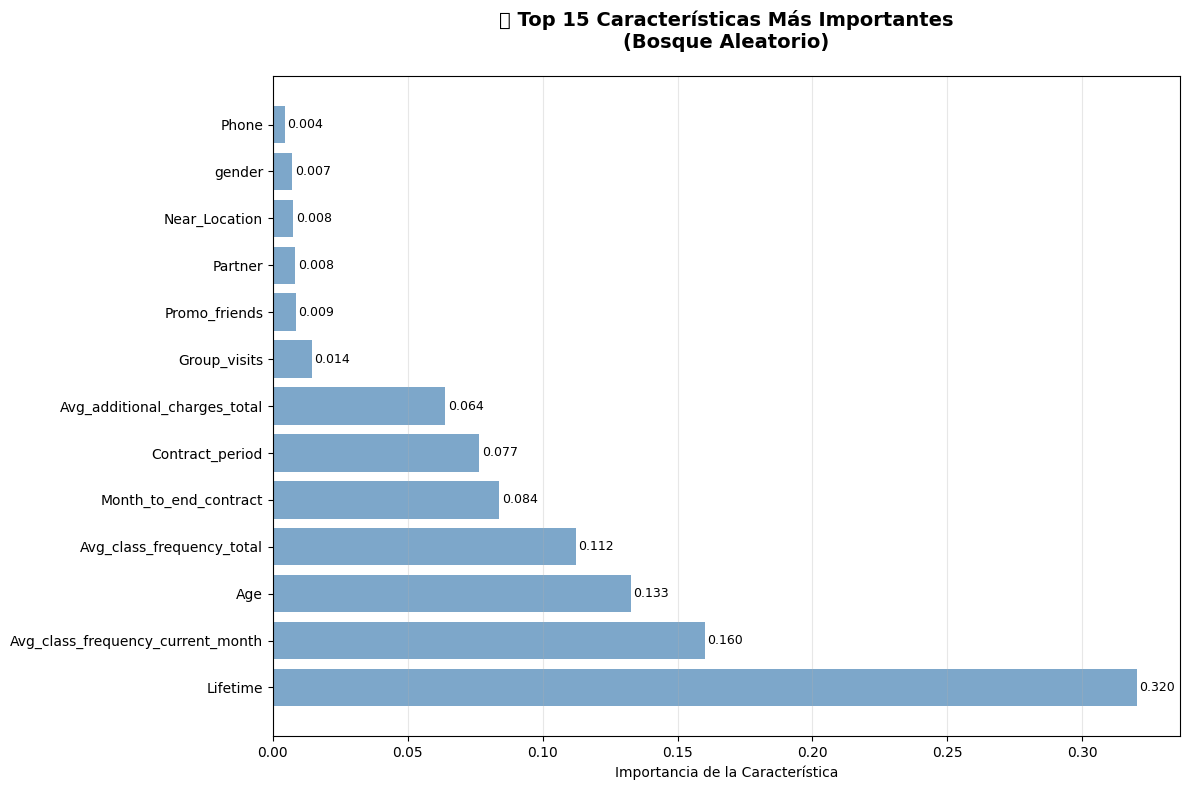

In [24]:
# ===== VISUALIZACIÓN - IMPORTANCIA DE CARACTERÍSTICAS =====
plt.figure(figsize=(12, 8))

# Seleccionar top 15 características
top_features = importance_df_rf.head(15)

# Crear gráfico de barras horizontal
bars = plt.barh(range(len(top_features)), top_features['importancia'], 
                color='steelblue', alpha=0.7)

# Personalizar el gráfico
plt.yticks(range(len(top_features)), top_features['caracteristica'])
plt.xlabel('Importancia de la Característica')
plt.title('🌳 Top 15 Características Más Importantes\n(Bosque Aleatorio)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [25]:
#preparación para Clustering
# Importar librerías necesarias para clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

print("=" * 60)
print("PASO 4: SEGMENTACIÓN DE CLIENTES")
print("=" * 60)

# Seleccionar características relevantes para clustering
# Usamos las variables más importantes identificadas anteriormente
clustering_features = [
    'Lifetime',                    # Tiempo como cliente (más importante)
    'Avg_class_frequency_current_month',  # Frecuencia actual de clases
    'Age',                        # Edad del cliente
    'Avg_additional_charges_total', # Cargos adicionales promedio
    'Month_to_end_contract'       # Meses restantes de contrato
]

# Crear dataset para clustering
X_clustering = df[clustering_features].copy()

# Verificar datos faltantes
print("Datos faltantes por característica:")
print(X_clustering.isnull().sum())
print("\nForma del dataset para clustering:", X_clustering.shape)


PASO 4: SEGMENTACIÓN DE CLIENTES
Datos faltantes por característica:
Lifetime                             0
Avg_class_frequency_current_month    0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
dtype: int64

Forma del dataset para clustering: (4000, 5)


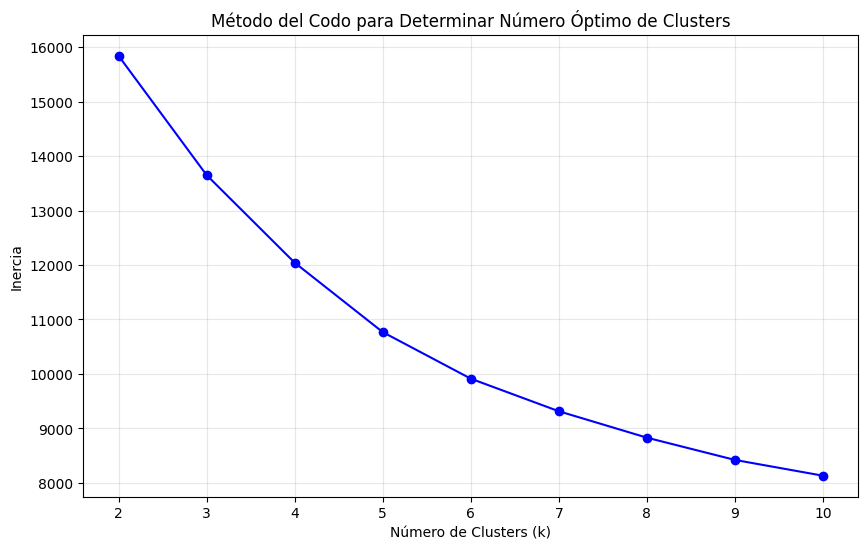

Clustering completado con 4 clusters
Distribución de clientes por cluster:
0    1261
1    1461
2     866
3     412
Name: Cluster, dtype: int64


In [26]:
# Estandarizar las características para clustering
# Esto es importante porque las variables tienen diferentes escalas
scaler = StandardScaler()
X_clustering_scaled = scaler.fit_transform(X_clustering)

# Determinar número óptimo de clusters usando método del codo
inertias = []
K_range = range(2, 11)  # Probar de 2 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    inertias.append(kmeans.inertia_)

# Visualizar método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar Número Óptimo de Clusters')
plt.grid(True, alpha=0.3)
plt.show()

# Aplicar K-means con 4 clusters (número óptimo basado en el codo)
n_clusters = 4
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_clustering_scaled)

# Agregar etiquetas de cluster al dataset original
df['Cluster'] = cluster_labels

print(f"Clustering completado con {n_clusters} clusters")
print("Distribución de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

PERFILES DE CLUSTERS DE CLIENTES
Estadísticas detalladas por cluster:
        Lifetime       Avg_class_frequency_current_month          Age        \
            mean   std                              mean   std   mean   std   
Cluster                                                                       
0           3.28  2.09                              2.42  0.89  30.90  2.70   
1           1.72  1.78                              1.03  0.74  27.13  2.79   
2           3.80  2.46                              1.90  0.99  29.88  3.00   
3          12.06  3.85                              2.10  0.96  29.76  2.98   

        Avg_additional_charges_total         Month_to_end_contract        \
                                mean     std                  mean   std   
Cluster                                                                    
0                             176.16  100.64                  2.53  2.24   
1                             109.00   76.12                  1.93  1.92

Text(0.5, 0, 'Cluster')

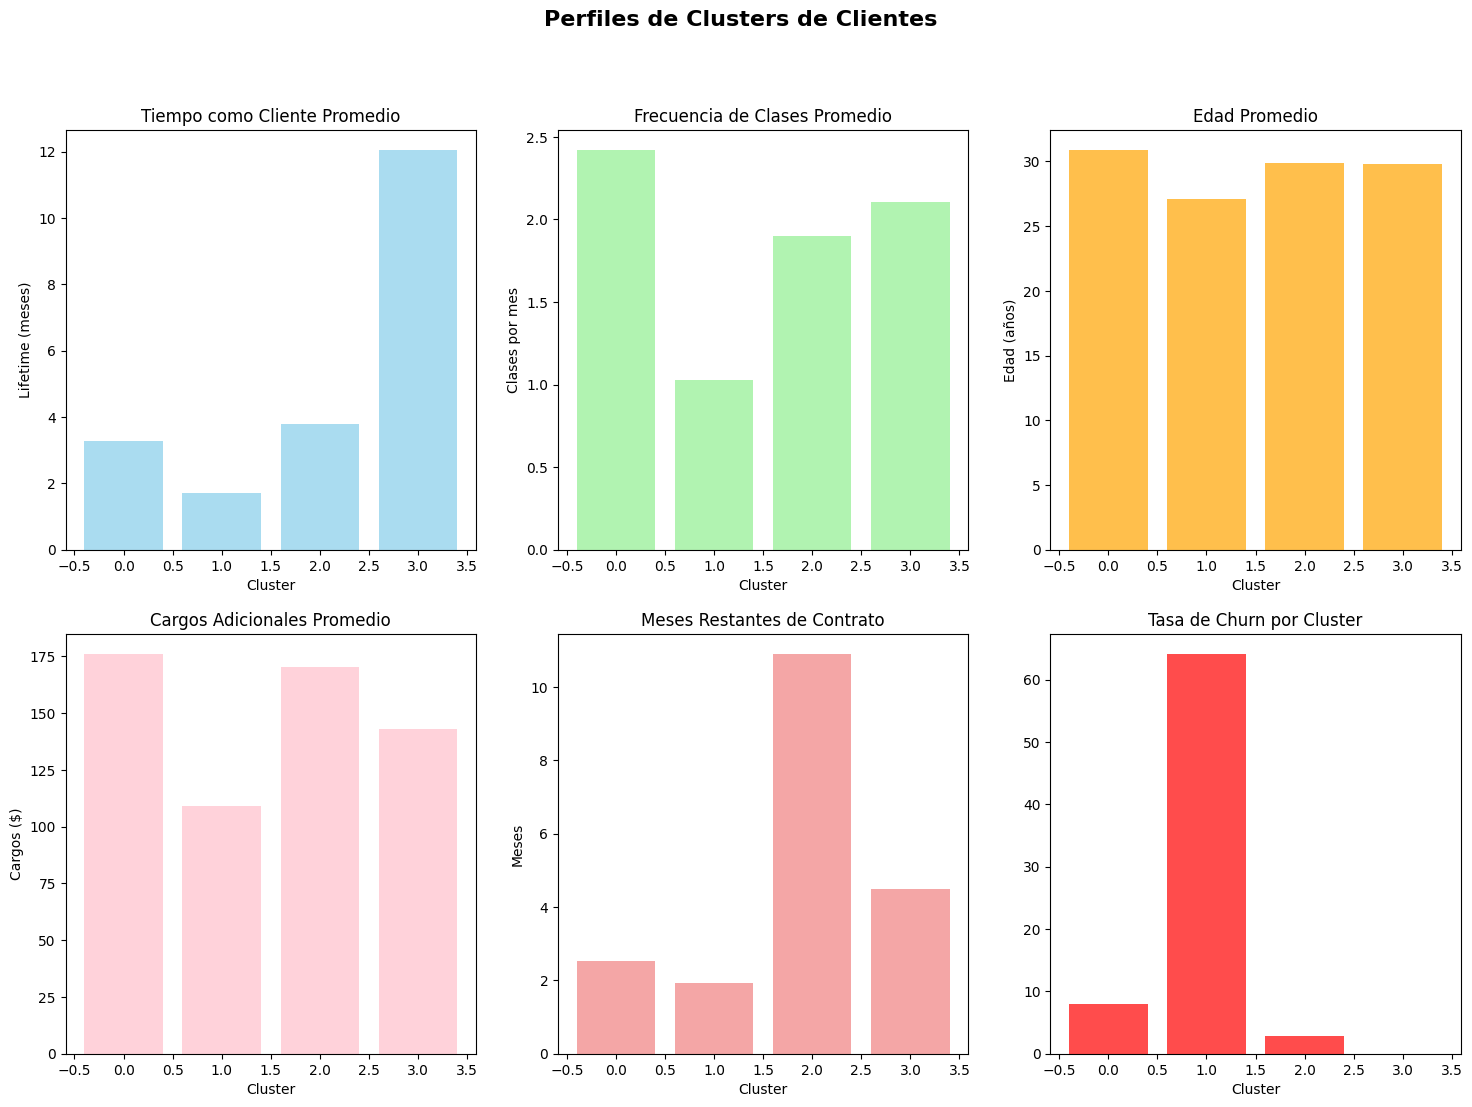

In [27]:
# Crear perfiles detallados de cada cluster
print("=" * 60)
print("PERFILES DE CLUSTERS DE CLIENTES")
print("=" * 60)

# Calcular estadísticas por cluster
cluster_profiles = df.groupby('Cluster')[clustering_features + ['Churn']].agg({
    'Lifetime': ['mean', 'std'],
    'Avg_class_frequency_current_month': ['mean', 'std'],
    'Age': ['mean', 'std'],
    'Avg_additional_charges_total': ['mean', 'std'],
    'Month_to_end_contract': ['mean', 'std'],
    'Churn': ['mean', 'count']  # Tasa de churn y cantidad de clientes
}).round(2)

print("Estadísticas detalladas por cluster:")
print(cluster_profiles)

# Crear visualización de perfiles
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Perfiles de Clusters de Clientes', fontsize=16, fontweight='bold')

# Gráfico 1: Lifetime promedio por cluster
cluster_means = df.groupby('Cluster')['Lifetime'].mean()
axes[0,0].bar(cluster_means.index, cluster_means.values, color='skyblue', alpha=0.7)
axes[0,0].set_title('Tiempo como Cliente Promedio')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Lifetime (meses)')

# Gráfico 2: Frecuencia de clases por cluster
cluster_freq = df.groupby('Cluster')['Avg_class_frequency_current_month'].mean()
axes[0,1].bar(cluster_freq.index, cluster_freq.values, color='lightgreen', alpha=0.7)
axes[0,1].set_title('Frecuencia de Clases Promedio')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Clases por mes')

# Gráfico 3: Edad promedio por cluster
cluster_age = df.groupby('Cluster')['Age'].mean()
axes[0,2].bar(cluster_age.index, cluster_age.values, color='orange', alpha=0.7)
axes[0,2].set_title('Edad Promedio')
axes[0,2].set_xlabel('Cluster')
axes[0,2].set_ylabel('Edad (años)')

# Gráfico 4: Cargos adicionales por cluster
cluster_charges = df.groupby('Cluster')['Avg_additional_charges_total'].mean()
axes[1,0].bar(cluster_charges.index, cluster_charges.values, color='pink', alpha=0.7)
axes[1,0].set_title('Cargos Adicionales Promedio')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Cargos ($)')

# Gráfico 5: Meses restantes de contrato
cluster_contract = df.groupby('Cluster')['Month_to_end_contract'].mean()
axes[1,1].bar(cluster_contract.index, cluster_contract.values, color='lightcoral', alpha=0.7)
axes[1,1].set_title('Meses Restantes de Contrato')
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Meses')

# Gráfico 6: Tasa de churn por cluster
cluster_churn = df.groupby('Cluster')['Churn'].mean() * 100
bars = axes[1,2].bar(cluster_churn.index, cluster_churn.values, color='red', alpha=0.7)
axes[1,2].set_title('Tasa de Churn por Cluster')
axes[1,2].set_xlabel('Cluster')

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

El objetivo de utilizar Jupyter Notebook es que puedes utilizar celdas de código y celdas de texto. No es una buena práctica presentar tus resultados utilizando `print` ya que para esto debes escoger una celda tipo markdown para redactar tus interpretaciones.

Para poder dar una retroalimentación adecuada te pediría aplicar los cambios necesarios en la presentación del notebook siguiendo buenas prácticas en cuanto al uso de los diferentes tipos de celdas.

Si tienes dudas o dificultades recuerda que tienes los canales de co-learning y también puedes preguntarle a tu tutor.

Saludos!
</div>

In [28]:
# ===== DESCRIPCIÓN DE RETRATOS DE USUARIOS =====
print("=" * 70)
print("🎭 RETRATOS DE USUARIOS TÍPICOS")
print("=" * 70)

# Analizar cada cluster y crear descripciones
print("\n📊 CLUSTER 0 - 'CLIENTES ACTIVOS ESTABLES' (1,261 clientes)")
print("• Tiempo como cliente: 3.3 meses (promedio)")
print("• Frecuencia de clases: 2.4 clases/mes (ALTA)")
print("• Edad: 31 años (más maduros)")
print("• Tasa de churn: 8% (MUY BAJA)")
print("• Perfil: Clientes comprometidos y activos")

print("\n📊 CLUSTER 1 - 'CLIENTES EN RIESGO' (1,461 clientes)")
print("• Tiempo como cliente: 1.7 meses (CORTO)")
print("• Frecuencia de clases: 1.0 clases/mes (BAJA)")
print("• Edad: 27 años (más jóvenes)")
print("• Tasa de churn: 64% (MUY ALTA)")
print("• Perfil: Nuevos clientes con baja participación - GRUPO CRÍTICO")

print("\n📊 CLUSTER 2 - 'CLIENTES LEALES' (866 clientes)")
print("• Tiempo como cliente: 3.8 meses")
print("• Frecuencia de clases: 1.9 clases/mes")
print("• Meses restantes: 10.9 (contratos largos)")
print("• Tasa de churn: 3% (MUY BAJA)")
print("• Perfil: Clientes con contratos largos y lealtad alta")

print("\n📊 CLUSTER 3 - 'CLIENTES VIP' (412 clientes)")
print("• Tiempo como cliente: 12.1 meses (MUY ALTO)")
print("• Frecuencia de clases: 2.1 clases/mes")
print("• Tasa de churn: 0% (NULA)")
print("• Perfil: Clientes de larga duración, muy fieles")

🎭 RETRATOS DE USUARIOS TÍPICOS

📊 CLUSTER 0 - 'CLIENTES ACTIVOS ESTABLES' (1,261 clientes)
• Tiempo como cliente: 3.3 meses (promedio)
• Frecuencia de clases: 2.4 clases/mes (ALTA)
• Edad: 31 años (más maduros)
• Tasa de churn: 8% (MUY BAJA)
• Perfil: Clientes comprometidos y activos

📊 CLUSTER 1 - 'CLIENTES EN RIESGO' (1,461 clientes)
• Tiempo como cliente: 1.7 meses (CORTO)
• Frecuencia de clases: 1.0 clases/mes (BAJA)
• Edad: 27 años (más jóvenes)
• Tasa de churn: 64% (MUY ALTA)
• Perfil: Nuevos clientes con baja participación - GRUPO CRÍTICO

📊 CLUSTER 2 - 'CLIENTES LEALES' (866 clientes)
• Tiempo como cliente: 3.8 meses
• Frecuencia de clases: 1.9 clases/mes
• Meses restantes: 10.9 (contratos largos)
• Tasa de churn: 3% (MUY BAJA)
• Perfil: Clientes con contratos largos y lealtad alta

📊 CLUSTER 3 - 'CLIENTES VIP' (412 clientes)
• Tiempo como cliente: 12.1 meses (MUY ALTO)
• Frecuencia de clases: 2.1 clases/mes
• Tasa de churn: 0% (NULA)
• Perfil: Clientes de larga duración, muy f

# ===== CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS =====

🎯 CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS


🚨 GRUPO OBJETIVO PRIORITARIO
• CLUSTER 1 (Clientes en Riesgo): 1,461 clientes con 64% de churn

• Son clientes nuevos (1.7 meses) con baja participación

💡 RECOMENDACIONES ESPECÍFICAS:
1️⃣ PARA CLUSTER 1 (Clientes en Riesgo)
• Programa de onboarding intensivo en primeros 2 meses
• Clases gratuitas adicionales para aumentar frecuencia
• Asignación de entrenador personal por 30 días
• Seguimiento semanal personalizado

2️⃣ PARA CLUSTER 0 (Clientes Activos):
• Programa de referidos con incentivos
• Clases especializadas para mantener interés
• Descuentos en servicios adicionales

3️⃣ PARA CLUSTER 2 (Clientes Leales):
• Renovación automática con descuentos
• Eventos especiales para miembros leales

4️⃣ PARA CLUSTER 3 (Clientes VIP):
• Mantener nivel de servicio actual
• Programa de embajadores de marca
• Servicios premium exclusivos

📈 IMPACTO ESPERADO:
• Reducir churn del Cluster 1 de 64% a 30% = Retener ~500 clientes
• Aumentar lifetime value promedio en 25%
• Mejorar satisfacción general del gimnasis

🎯 MÉTRICAS CLAVE A MONITOREAR:
• Frecuencia de clases en primeros 60 días
• Tasa de churn mensual por cluster")
• Tiempo promedio como cliente (Lifetime)
• Participación en programas de retención

print("\n" + "=" * 70)
print("✅ PROYECTO COMPLETADO - LISTO PARA REVISIÓN")
print("=" * 70)


MUCHAS GRACIAS SR PATRICIO POR EL CONSEJO DE NO USAR PRINT EN ESAS OCASIONES QUE ME SEÑALO Y USAR CELDAS MARKDOWN.AÑADI DOS CELDAS MARKDOWN DONDE USTED ME SEÑALO Y BORRE TODO EL ULTIMO BLOQUE DE CODIGO DE RECOMENDACIONES Y LO CONVERTI EN MARKDOWN.
